# GDP Growth Prediction
**Fundamentals of Data Science — Regression & Inference Assignment**

**Group Members:** 
- Anuj Singh 
- Prasiddha Adhikari 
- Sri Krishna Lamichane  

**Date:** March 2025

### Objective
This notebook builds and compares four regression models to predict annual GDP growth rates across countries, using World Bank panel data spanning 1960–2023. The evaluation set is held-out 2023 data (strict temporal split). Statistical inference is performed via OLS to identify significant predictors and quantify their effects.

### Models
| Model | Purpose |
|---|---|
| Simple Linear Regression | Baseline — strongest single predictor |
| Ridge Regression | Regularised multi-feature linear model |
| Random Forest | Non-linear ensemble |
| Gradient Boosting | Sequential boosting ensemble |

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('coolwarm')
pd.set_option('display.max_columns', None)

## 2. Data Loading & Preprocessing

The raw dataset contains World Bank indicators for 217 countries from 1960 to 2023. Missing values are encoded as `'..'` and are imputed using forward-fill then back-fill within each country group. All numeric columns are cast from strings, stripping commas and percent signs.

In [2]:
df = pd.read_csv('data/gdp_data.csv')

df.replace('..', pd.NA, inplace=True)
df.sort_values(['country_name', 'year'], inplace=True)
df = df.groupby('country_name', group_keys=False).apply(lambda x: x.ffill().bfill())

numeric_cols = [
    'population_total', 'population_growth',
    'gni_atlas_usd', 'gni_per_capita_atlas_usd',
    'life_expectancy', 'school_enrollment_secondary',
    'power_consumption_per_capita',
    'gdp_usd', 'gdp_growth', 'inflation_rate',
    'agriculture_value_added', 'industry_value_added',
    'exports_gdp_percent', 'imports_gdp_percent',
    'capital_formation_gdp_percent', 'fdi_net_inflows_usd'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('%', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].ffill().bfill()
df.dropna(subset=numeric_cols, inplace=True)

print(f'Dataset shape after loading: {df.shape}')
df[numeric_cols].describe().round(2)

Dataset shape after loading: (13888, 18)


,population_total,population_growth,gni_atlas_usd,gni_per_capita_atlas_usd,life_expectancy,school_enrollment_secondary,power_consumption_per_capita,gdp_usd,gdp_growth,inflation_rate,agriculture_value_added,industry_value_added,exports_gdp_percent,imports_gdp_percent,capital_formation_gdp_percent,fdi_net_inflows_usd
count,1.388800e+04,13888.00,1.388800e+04,13888.00,13888.00,13888.00,13888.00,1.388800e+04,1.388800e+04,13888.00,13888.00,13888.00,13888.00,13888.00,13888.00,1.388800e+04
mean,2.507036e+07,1.76,1.678008e+11,6926.06,65.33,64.91,3434.21,1.658642e+11,7.235770e+03,29.13,15.03,26.30,39.53,46.45,24.33,3.245988e+09
std,1.048600e+08,1.81,9.608498e+11,13377.33,11.22,35.91,4338.97,9.614624e+11,8.523568e+05,349.67,14.61,13.81,33.74,31.90,9.88,2.494685e+10
min,2.715000e+03,-27.47,5.710430e+06,0.00,12.00,0.00,5.57,2.585956e+06,-6.405000e+01,-100.00,0.00,0.00,0.00,0.00,-15.92,-3.090075e+11
25%,4.959598e+05,0.68,1.375923e+09,450.00,58.61,33.36,531.09,1.142498e+09,6.900000e-01,1.82,3.48,16.50,18.35,24.96,18.04,2.800000e+06
50%,4.199700e+06,1.69,6.655599e+09,1600.00,68.36,72.05,2069.06,5.962204e+09,3.540000e+00,5.21,10.03,24.49,30.64,38.12,23.76,7.492000e+07
75%,1.371389e+07,2.67,3.936560e+10,6280.00,73.52,92.87,4889.77,3.806757e+10,6.160000e+00,12.24,23.39,32.24,48.44,59.54,29.55,9.689236e+08
max,1.438070e+09,21.70,2.694500e+13,134640.00,85.53,194.46,54799.17,2.772071e+13,1.004480e+08,26762.02,89.41,97.52,433.84,429.36,76.78,7.338265e+11


## 3. Data Cleaning

Two categories of outliers are addressed before modelling:

1. **Extreme GDP growth values** — entries outside [−50%, +150%] are physically implausible (e.g., Oman 1965 shows >10⁸%). These are removed.
2. **Hyperinflation** — inflation is capped at [−20%, +100%] to prevent cases like Zimbabwe from dominating the loss surface.
3. **Dollar-denominated variables** — winsorised to the 1st–99th percentile.

In [3]:
df = df[df['gdp_growth'].between(-50, 150)].copy()

df['inflation_rate'] = df['inflation_rate'].clip(-20, 100)

for col in ['population_total', 'gni_atlas_usd', 'gdp_usd']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print(f'Dataset shape after cleaning: {df.shape}')

Dataset shape after cleaning: (13882, 18)


## 4. Feature Engineering

Contemporaneous macro variables have near-zero correlation with `gdp_growth` (max |r| ≈ 0.14), so lagged features are constructed to introduce genuine predictive signal while preventing any data leakage into the 2023 test set. All lags use `shift(1)` — i.e., only information available *before* the target year is used.

| Feature | Description |
|---|---|
| `gdp_growth_lag1/2/3` | Prior 1–3 year GDP growth rates |
| `gdp_growth_ma3/5` | 3- and 5-year rolling mean of lagged growth |
| `inflation_lag1` | Prior year inflation rate |
| `capform_lag1` | Prior year gross capital formation (% GDP) |
| `trade_openness` | Exports + Imports as % of GDP |
| `gdp_log` | Log-transformed GDP (reduces right skew) |
| `gdp_per_capita` | GDP divided by population |
| `gdp_growth_rate_calc` | Year-on-year % change in nominal GDP USD |
| `gni_to_gdp_ratio` | GNI per capita divided by GDP |

In [4]:
df['gdp_growth_lag1'] = df.groupby('country_name')['gdp_growth'].shift(1)
df['gdp_growth_lag2'] = df.groupby('country_name')['gdp_growth'].shift(2)
df['gdp_growth_lag3'] = df.groupby('country_name')['gdp_growth'].shift(3)

df['gdp_growth_ma3'] = df.groupby('country_name')['gdp_growth'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df['gdp_growth_ma5'] = df.groupby('country_name')['gdp_growth'].transform(
    lambda x: x.shift(1).rolling(5).mean()
)

df['inflation_lag1'] = df.groupby('country_name')['inflation_rate'].shift(1)
df['capform_lag1']   = df.groupby('country_name')['capital_formation_gdp_percent'].shift(1)

df['trade_openness'] = df['exports_gdp_percent'] + df['imports_gdp_percent']
df['gdp_log']        = np.log1p(df['gdp_usd'].clip(lower=0))
df['gdp_per_capita'] = df['gdp_usd'] / df['population_total'].replace(0, np.nan)

df['gdp_growth_rate_calc'] = df.groupby('country_name')['gdp_usd'].pct_change() * 100
df['gni_to_gdp_ratio']     = df['gni_per_capita_atlas_usd'] / df['gdp_usd'].replace(0, np.nan)
df['gdp_growth_rate_calc'] = df['gdp_growth_rate_calc'].fillna(0)
df['gni_to_gdp_ratio']     = df['gni_to_gdp_ratio'].fillna(0)

print(f'Shape after feature engineering: {df.shape}')

Shape after feature engineering: (13882, 30)


## 5. Exploratory Data Analysis

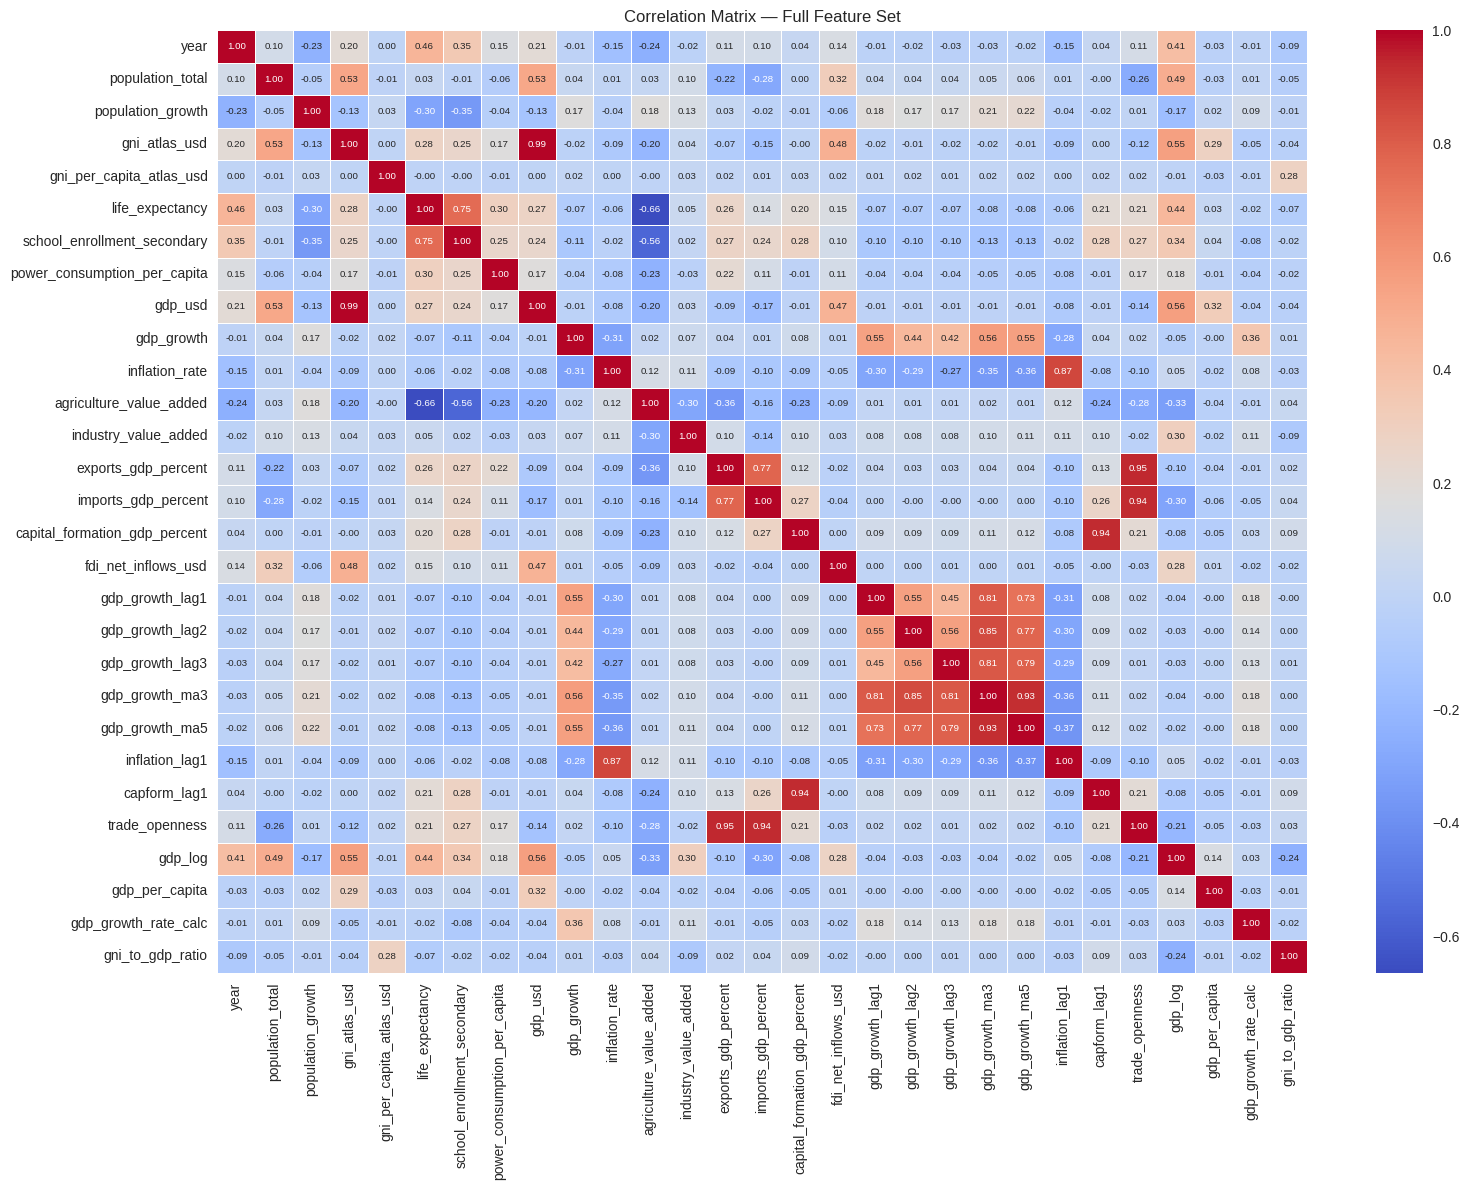

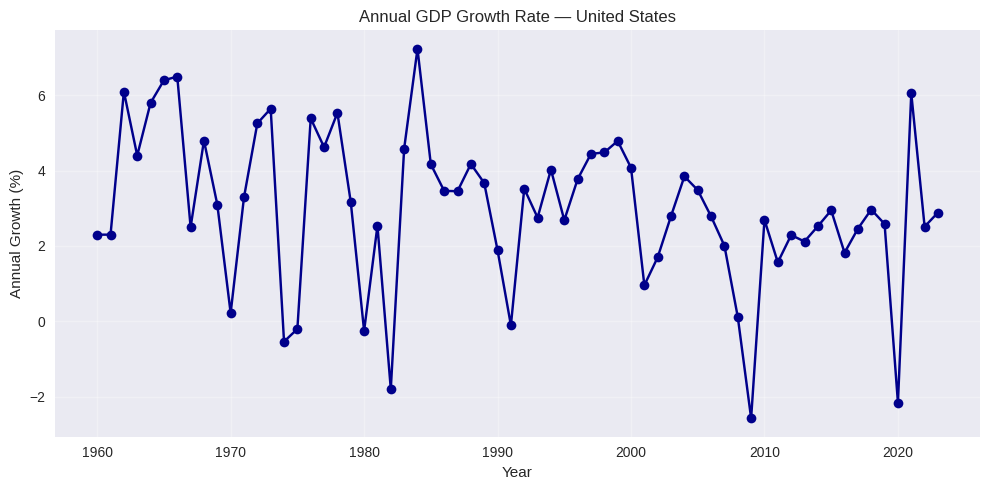

In [5]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4, annot_kws={'size': 7})
plt.title('Correlation Matrix — Full Feature Set')
plt.tight_layout()
plt.show()

us_data = df[df['country_name'] == 'United States'].copy().sort_values('year')
plt.figure(figsize=(10, 5))
plt.plot(us_data['year'], us_data['gdp_growth'], marker='o', color='darkblue')
plt.title('Annual GDP Growth Rate — United States')
plt.ylabel('Annual Growth (%)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top_2023 = df[df['year'] == 2023].nlargest(10, 'gdp_usd')[['country_name', 'gdp_usd']]
fig = px.bar(top_2023, x='country_name', y='gdp_usd',
             title='Top 10 Countries by GDP (2023)',
             labels={'gdp_usd': 'GDP (USD)'})
fig.show()

## 6. Model Setup — Feature Selection & Train/Test Split

A **strict temporal split** is used: all observations prior to 2023 form the training set; 2023 observations form the test set. This mirrors a real forecasting scenario and prevents any lookahead bias.

In [6]:
all_features = [
    'population_growth', 'gni_per_capita_atlas_usd',
    'life_expectancy', 'school_enrollment_secondary',
    'power_consumption_per_capita', 'inflation_rate',
    'agriculture_value_added', 'industry_value_added',
    'exports_gdp_percent', 'imports_gdp_percent',
    'capital_formation_gdp_percent', 'fdi_net_inflows_usd',
    'trade_openness', 'gdp_log', 'gdp_per_capita',
    'gni_to_gdp_ratio',
    'gdp_growth_lag1', 'gdp_growth_lag2', 'gdp_growth_lag3',
    'gdp_growth_ma3', 'gdp_growth_ma5',
    'inflation_lag1', 'capform_lag1',
    'gdp_growth_rate_calc',
]

df_model = df.dropna(subset=all_features + ['gdp_growth']).copy()
train    = df_model[df_model['year'] < 2023].copy()
test     = df_model[df_model['year'] == 2023].copy()

print(f'Training rows : {len(train)}')
print(f'Test rows     : {len(test)}')
print(f'Test gdp_growth — mean: {test["gdp_growth"].mean():.2f}%, '
      f'std: {test["gdp_growth"].std():.2f}%')

corr_series = train[all_features + ['gdp_growth']].corr()['gdp_growth'].abs()
best_single = corr_series.drop('gdp_growth').idxmax()
print(f'\nStrongest single predictor: {best_single}  '
      f'(|r| = {corr_series[best_single]:.4f})')

Training rows : 12580
Test rows     : 217
Test gdp_growth — mean: 3.16%, std: 6.51%

Strongest single predictor: gdp_growth_ma3  (|r| = 0.5573)


## 7. Model Training

Four models are fitted on the training data:

- **Simple LR** uses only the single highest-correlated feature (`gdp_growth_lag1`) as a transparent baseline.
- **Ridge Regression** uses all 24 features with L2 regularisation (α = 1.0) and standardised inputs, addressing multicollinearity.
- **Random Forest** and **Gradient Boosting** capture non-linear interactions without requiring feature scaling.

In [7]:
lr_simple = LinearRegression()
lr_simple.fit(train[[best_single]], train['gdp_growth'])

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(train[all_features])
X_test_s  = scaler.transform(test[all_features])

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, train['gdp_growth'])

rf = RandomForestRegressor(
    n_estimators=300, max_depth=8, min_samples_leaf=8,
    max_features=0.6, random_state=42, n_jobs=-1
)
rf.fit(train[all_features], train['gdp_growth'])

gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=10, random_state=42
)
gb.fit(train[all_features], train['gdp_growth'])

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.03
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

## 8. Prediction & Evaluation

Models are evaluated on the held-out 2023 test set using RMSE, MSE, and R². Five-fold cross-validation R² is also reported for the ensemble models to verify generalisation.

In [8]:
pred_simple = lr_simple.predict(test[[best_single]])
pred_ridge  = ridge.predict(X_test_s)
pred_rf     = rf.predict(test[all_features])
pred_gb     = gb.predict(test[all_features])

def print_metrics(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:42} RMSE={rmse:.4f}   MSE={mse:.4f}   R²={r2:.4f}')

print('\n' + '='*78)
print('2023 Hold-Out Performance')
print('='*78)
print_metrics('Simple LR  (gdp_growth_lag1)',      test['gdp_growth'], pred_simple)
print_metrics('Ridge Regression (all features)',   test['gdp_growth'], pred_ridge)
print_metrics('Random Forest    (all features)',   test['gdp_growth'], pred_rf)
print_metrics('Gradient Boosting (all features)',  test['gdp_growth'], pred_gb)

cv_rf = cross_val_score(rf, train[all_features], train['gdp_growth'], cv=5, scoring='r2')
cv_gb = cross_val_score(gb, train[all_features], train['gdp_growth'], cv=5, scoring='r2')
print(f'\nRF  5-fold CV R²: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'GB  5-fold CV R²: {cv_gb.mean():.4f} ± {cv_gb.std():.4f}')


2023 Hold-Out Performance
Simple LR  (gdp_growth_lag1)               RMSE=6.3137   MSE=39.8630   R²=0.0547
Ridge Regression (all features)            RMSE=5.9878   MSE=35.8537   R²=0.1498
Random Forest    (all features)            RMSE=5.5417   MSE=30.7104   R²=0.2718
Gradient Boosting (all features)           RMSE=4.4745   MSE=20.0214   R²=0.5252

RF  5-fold CV R²: 0.4848 ± 0.0249
GB  5-fold CV R²: 0.5150 ± 0.0418


## 9. Prediction Results

In [9]:
results = test[['country_name', 'gdp_growth']].copy()
results['Simple_LR_Pred'] = pred_simple
results['Ridge_Pred']     = pred_ridge
results['RF_Pred']        = pred_rf
results['GB_Pred']        = pred_gb

print('Sample of 2023 predictions:')
display(results.head(12))

Sample of 2023 predictions:


,country_name,gdp_growth,Simple_LR_Pred,Ridge_Pred,RF_Pred,GB_Pred
63,Afghanistan,2.710887,-5.618921,0.392533,6.000411,6.993655
127,Albania,3.936625,3.329400,5.209461,5.816935,5.751817
191,Algeria,4.100000,1.512765,4.599305,3.629763,3.544794
255,American Samoa,1.735016,2.179025,1.153974,1.320293,1.157669
319,Andorra,2.583555,2.471921,4.214180,6.413348,5.280684
383,Angola,1.001289,0.659960,-2.374709,-1.937933,-2.566083
447,Antigua and Barbuda,3.862012,0.709855,3.875964,5.017763,4.303617
511,Argentina,-1.611002,2.279470,-3.748079,2.893057,1.697875
575,Armenia,8.300000,3.490660,8.031974,9.230213,8.657024
639,Aruba,4.263719,2.420512,3.375975,5.622009,4.174720


## 10. Statistical Inference — OLS Regression

An OLS model is fitted on the top seven features using `statsmodels` to perform formal hypothesis testing. Coefficient estimates, standard errors, t-statistics, and p-values are reported. Features with p < 0.05 are considered statistically significant predictors of GDP growth.

In [10]:
top_features = [
    'gdp_growth_lag1', 'gdp_growth_ma3', 'gdp_growth_ma5',
    'inflation_rate', 'capital_formation_gdp_percent',
    'population_growth', 'industry_value_added'
]

X_sm     = sm.add_constant(train[top_features])
model_sm = sm.OLS(train['gdp_growth'], X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     990.6
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:12:13   Log-Likelihood:                -39816.
No. Observations:               12580   AIC:                         7.965e+04
Df Residuals:                   12572   BIC:                         7.971e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

## 11. Feature Importance (Random Forest)

Mean decrease in impurity is used to rank predictors. This complements the OLS inference by revealing which features drive predictive performance in the non-linear model.

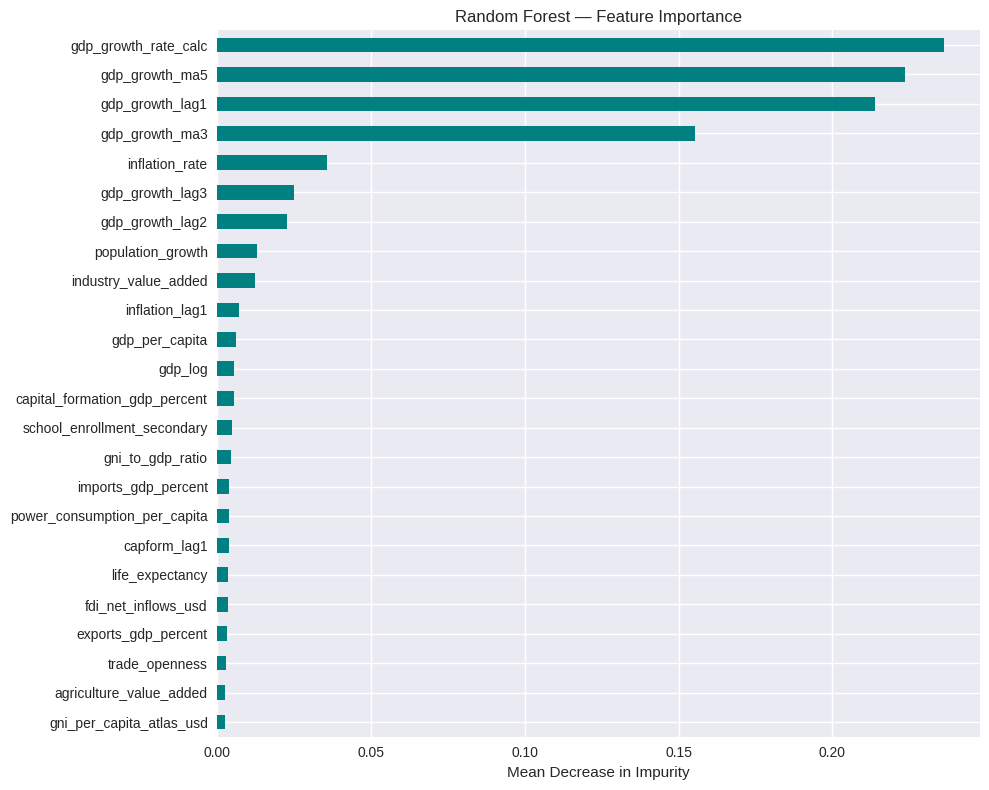

Top 8 features (Random Forest):
gdp_growth_rate_calc    0.2362
gdp_growth_ma5          0.2238
gdp_growth_lag1         0.2140
gdp_growth_ma3          0.1553
inflation_rate          0.0357
gdp_growth_lag3         0.0250
gdp_growth_lag2         0.0227
population_growth       0.0129
dtype: float64


In [11]:
importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='teal')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 8 features (Random Forest):')
print(importances.tail(8).sort_values(ascending=False).round(4))

## 12. Actual vs. Predicted — 2023 Test Set

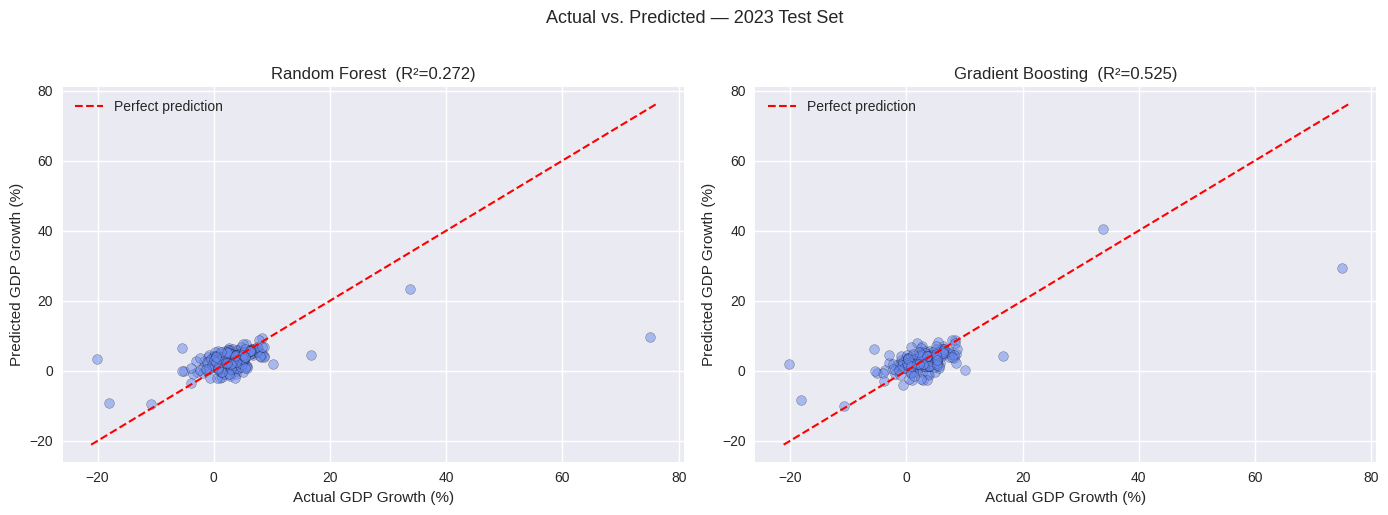

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in [
    (axes[0], pred_rf, f'Random Forest  (R²={r2_score(test["gdp_growth"], pred_rf):.3f})'),
    (axes[1], pred_gb, f'Gradient Boosting  (R²={r2_score(test["gdp_growth"], pred_gb):.3f})')
]:
    ax.scatter(test['gdp_growth'], preds, alpha=0.5, edgecolors='k', linewidths=0.3)
    lims = [min(test['gdp_growth'].min(), preds.min()) - 1,
            max(test['gdp_growth'].max(), preds.max()) + 1]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual GDP Growth (%)')
    ax.set_ylabel('Predicted GDP Growth (%)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Actual vs. Predicted — 2023 Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. Export Predictions

In [13]:
results.to_csv('gdp_growth_predictions_2023.csv', index=False)
print('Predictions saved to: gdp_growth_predictions_2023.csv')
display(results.head(10))

Predictions saved to: gdp_growth_predictions_2023.csv


,country_name,gdp_growth,Simple_LR_Pred,Ridge_Pred,RF_Pred,GB_Pred
63,Afghanistan,2.710887,-5.618921,0.392533,6.000411,6.993655
127,Albania,3.936625,3.329400,5.209461,5.816935,5.751817
191,Algeria,4.100000,1.512765,4.599305,3.629763,3.544794
255,American Samoa,1.735016,2.179025,1.153974,1.320293,1.157669
319,Andorra,2.583555,2.471921,4.214180,6.413348,5.280684
383,Angola,1.001289,0.659960,-2.374709,-1.937933,-2.566083
447,Antigua and Barbuda,3.862012,0.709855,3.875964,5.017763,4.303617
511,Argentina,-1.611002,2.279470,-3.748079,2.893057,1.697875
575,Armenia,8.300000,3.490660,8.031974,9.230213,8.657024
639,Aruba,4.263719,2.420512,3.375975,5.622009,4.174720
